In [1]:
import numpy as np
import os, glob, sys, argparse
import multiprocessing as mp
from getdist import loadMCSamples
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
camb_mod_path = "/home/camilo/cocoa/Cocoa/external_modules/code/CAMB_GammaPrime_Growth"
sys.path.insert(0, camb_mod_path)
import camb
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

Using CAMB 1.3.6 installed at /home/camilo/cocoa/Cocoa/external_modules/code/CAMB_GammaPrime_Growth/camb


In [2]:
H0, Ombh2, Ocdmh2, As, ns, Ok, gamma = [70,0.022,0.12,2e-9,0.96,0,0.55]
redshifts = [0.295,0.510,0.706,0.930,1.317,1.491]
# Set up CAMB parameters
pars = camb.CAMBparams()

# Set basic cosmology
pars.set_cosmology(H0=H0, ombh2=Ombh2, omch2=Ocdmh2, omk=Ok, gamma0=gamma, gamma1=0.0)
pars.InitPower.set_params(As=As, ns=ns)

z_all = np.concatenate([[0.0], redshifts])
sort_idx = np.argsort(z_all)[::-1]
z_sorted = z_all[sort_idx]
pars.set_matter_power(redshifts=z_sorted, kmax=10.0)

# Run CAMB
results = camb.get_results(pars)

# --- Compute growth factor D(z) for f ---
# --- 1. Create a z grid ---
z_dense = np.linspace(0, max(z_all), 500)

# --- 2. Omega_m(z) from CAMB ---
H_dense = results.hubble_parameter(z_dense)

Omega_m0 = (Ombh2 + Ocdmh2) / (H0/100.0)**2
Ez2_dense = (H_dense / H0)**2
Omega_m_dense = Omega_m0 * (1 + z_dense)**3 / Ez2_dense

# --- 3. f(z) ---
f_dense = Omega_m_dense**gamma

# --- 4. Manual cumulative integral ---
integrand = f_dense / (1 + z_dense)
dz = np.diff(z_dense)
I = np.zeros_like(z_dense)
I[1:] = np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * dz)

# --- 5. Growth factor ---
D_dense = np.exp(-I)

# --- 6. sigma8 ---
sigma8_0 = results.get_sigma8()[-1]  # sigma8 at z=0 from CAMB
sigma8_dense = sigma8_0 * D_dense

# --- 7. fsigma8 ---
fsigma8_dense = f_dense * sigma8_dense

# --- 8. Interpolate ---
#interp_sigma8 = interp1d(z_dense, sigma8_dense, kind='cubic')
#interp_f = interp1d(z_dense, f_dense, kind='cubic')
interp_fsigma8 = interp1d(z_dense, fsigma8_dense, kind='cubic')
#interp_Om = interp1d(z_dense, Omega_m_dense, kind='cubic')

#sigma8_final = interp_sigma8(z_all)
#f_final = interp_f(z_all)
fs8 = interp_fsigma8(redshifts)

In [18]:
kh, z_pk, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints = 200)
mask = kh < 0.1
D_pk = np.sqrt(np.mean(pk[:, mask] / pk[0, mask], axis=1))

Add D(z) from original CAMB, compare with gammaprime 0.55 and 1.1. Do the same with Pk, sigma8, f and fsigma8.

In [3]:
def compute_fsigma8_camb(gamma, redshifts=[0.295,0.510,0.706,0.930,1.317,1.491]):
    #H0, Ombh2, Ocdmh2, As, ns, Ok, gamma = theta_fs8
    H0, Ombh2, Ocdmh2, As, ns, Ok = [70,0.022,0.12,2e-9,0.96,0]
    # Set up CAMB parameters
    pars = camb.CAMBparams()
    
    # Set basic cosmology
    pars.set_cosmology(H0=H0, ombh2=Ombh2, omch2=Ocdmh2, omk=Ok, gamma0=gamma, gamma1=0.0)
    pars.InitPower.set_params(As=As, ns=ns)

    z_all = np.concatenate([[0.0], redshifts])
    sort_idx = np.argsort(z_all)[::-1]
    z_sorted = z_all[sort_idx]
    pars.set_matter_power(redshifts=z_sorted, kmax=10.0)

    # Run CAMB
    results = camb.get_results(pars)
    kh, z_pk, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints = 200)

    # --- Compute growth factor D(z) for f ---
    # --- 1. Create a z grid ---
    z_dense = np.linspace(0, max(z_all), 500)

    # --- 2. Omega_m(z) from CAMB ---
    H_dense = results.hubble_parameter(z_dense)

    Omega_m0 = (Ombh2 + Ocdmh2) / (H0/100.0)**2
    Ez2_dense = (H_dense / H0)**2
    Omega_m_dense = Omega_m0 * (1 + z_dense)**3 / Ez2_dense

    # --- 3. f(z) ---
    f_dense = Omega_m_dense**gamma

    # --- 4. Manual cumulative integral ---
    integrand = f_dense / (1 + z_dense)
    dz = np.diff(z_dense)
    I = np.zeros_like(z_dense)
    I[1:] = np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * dz)

    # --- 5. Growth factor ---
    D_dense = np.exp(-I)

    # --- 6. sigma8 ---
    sigma8_0 = results.get_sigma8()[-1]  # sigma8 at z=0 from CAMB
    sigma8_dense = sigma8_0 * D_dense

    # --- 7. fsigma8 ---
    fsigma8_dense = f_dense * sigma8_dense

    # --- 8. Interpolate ---
    interp_sigma8 = interp1d(z_dense, sigma8_dense, kind='cubic')
    interp_f = interp1d(z_dense, f_dense, kind='cubic')
    interp_fsigma8 = interp1d(z_dense, fsigma8_dense, kind='cubic')
    #interp_Om = interp1d(z_dense, Omega_m_dense, kind='cubic')

    sigma8_final = interp_sigma8(z_all)
    f_final = interp_f(z_all)
    fs8 = interp_fsigma8(redshifts)

    return kh, z_pk, pk,z_dense, D_dense, fs8, sigma8_final, f_final

In [4]:
kh_0, z_pk_0, pk_0,z_dense_0, D_dense_0, fs8_0, sigma8_final_0, f_final_0 = compute_fsigma8_camb(0.55)
kh_1, z_pk_1, pk_1,z_dense_1, D_dense_1, fs8_1, sigma8_final_1, f_final_1 = compute_fsigma8_camb(1.1)

In [5]:
data = np.loadtxt("./CAMB-original_z0p0_results.txt")

z_orig = data[:, 0]
sigma8_orig = data[:, 1]
f_orig = data[:, 3]
fs8_orig = data[:, 4]

In [13]:
data_camb_orig = np.load('./pklin_all.npz')
kh = data_camb_orig['kh']
z = data_camb_orig['z']
pk_lin = data_camb_orig['pk']

mask = kh < 0.1
D_pk = np.sqrt(np.mean(pk_0[:, mask] / pk_0[0, mask], axis=1))

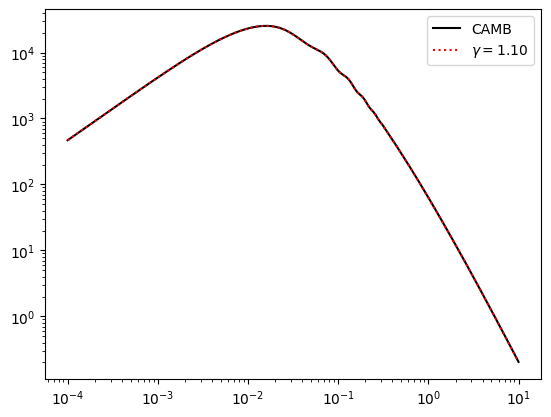

In [15]:
plt.loglog(kh,pk_lin[0,:],ls='-',c='k',label=r'CAMB')
plt.loglog(kh_0,pk_0[0,:],ls='--',c='b',label=r'$\gamma = 0.55$')
plt.loglog(kh_1,pk_1[0,:],ls=':',c='r',label=r'$\gamma = 1.10$')

plt.legend()
plt.show()

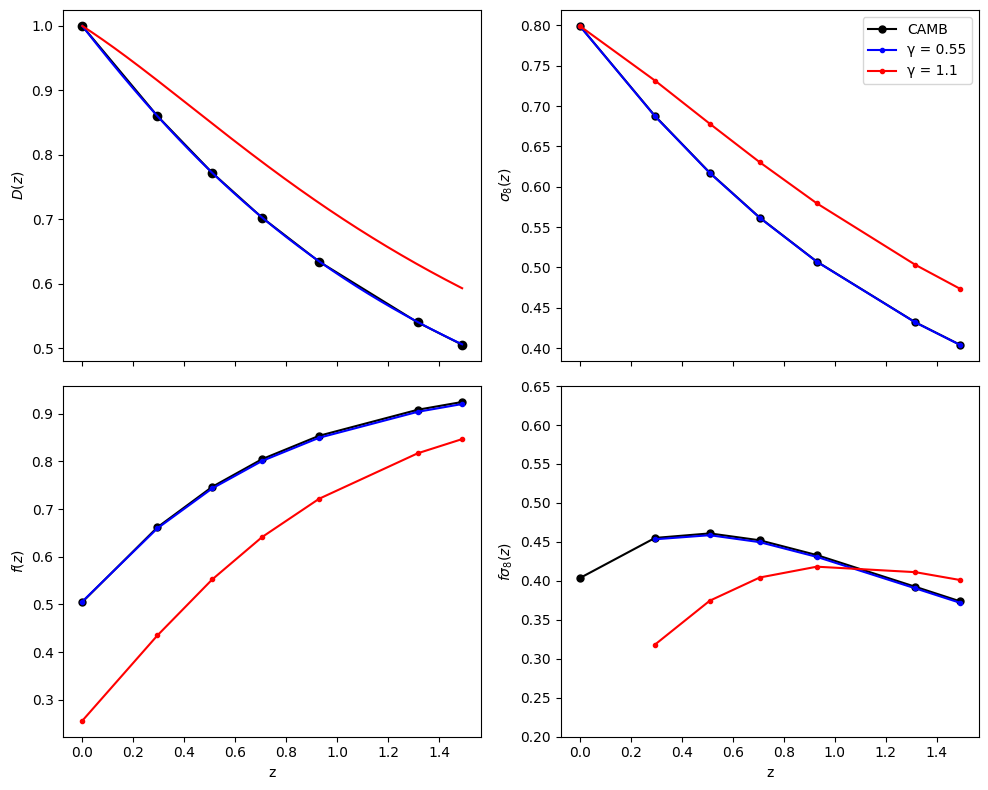

In [16]:
# --- Create figure ---
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True)

# Labels for legend
labels = ["CAMB", "γ = 0.55", "γ = 1.1"]
colors = ["black", "blue", "red"]
ls = ['-','--','-']

# --- σ8 ---
axs[0, 1].plot(z_orig,sigma8_orig,'o-',ms=5, label=labels[0], color=colors[0])
axs[0, 1].plot(z_pk_0,sigma8_final_0,'o-',ms=3, label=labels[1], color=colors[1])
axs[0, 1].plot(z_pk_1,sigma8_final_1,'o-',ms=3, label=labels[2], color=colors[2])

axs[0, 1].set_ylabel(r"$\sigma_8(z)$")
axs[0, 1].legend()

# --- D ---
axs[0, 0].set_ylabel(r"$D(z)$")
axs[0, 0].plot(z, D_pk,'o-', label=labels[0], color=colors[0])
axs[0, 0].plot(z_dense_0, D_dense_0, label=labels[1], color=colors[1])
axs[0, 0].plot(z_dense_1, D_dense_1, label=labels[2], color=colors[2])

# --- f ---
axs[1, 0].plot(z_orig,f_orig,'o-',ms=5, color=colors[0])
axs[1, 0].plot(z_pk_0,f_final_0,'o-',ms=3, color=colors[1])
axs[1, 0].plot(z_pk_1,f_final_1,'o-',ms=3, color=colors[2])
axs[1, 0].set_ylabel(r"$f(z)$")
axs[1, 0].set_xlabel("z")

# --- fσ8 ---
axs[1, 1].plot(z_orig,fs8_orig,'o-',ms=5, color=colors[0])
axs[1, 1].plot(z_pk_0[1:],fs8_0,'o-',ms=3, color=colors[1])
axs[1, 1].plot(z_pk_1[1:],fs8_1,'o-',ms=3, color=colors[2])

axs[1, 1].set_ylim(0.2, 0.65)
axs[1, 1].set_ylabel(r"$f\sigma_8(z)$")
axs[1, 1].set_xlabel("z")

# --- Layout ---
plt.tight_layout()
plt.show()